In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(data.table)
    library(stringr)
    library(dplyr)
    library(parallel)
    library(glue)
    library(patchwork)
    library(ape)
    library(igraph)
    library(ggtree)
    library(ggraph)
    library(ggpubr)
    library(tidygraph)
    library(ggrepel)
    library(ggtreeExtra)
    library(redeemR)
    library(Seurat)
    library(Signac)
    library(mitodrift)
})

filter = dplyr::filter
options(repr.matrix.max.cols=15, repr.matrix.max.rows=50)
rename = dplyr::rename
R.utils::sourceDirectory('../../R')
R.utils::sourceDirectory('../../../tools/mitodrift/R')

Warning message:
“package ‘data.table’ was built under R version 4.4.3”
Warning message:
“package ‘ggpubr’ was built under R version 4.4.3”
Warning message:
“replacing previous import ‘data.table::first’ by ‘dplyr::first’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘ape::where’ by ‘dplyr::where’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘data.table::last’ by ‘dplyr::last’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘data.table::between’ by ‘dplyr::between’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘data.table::melt’ by ‘reshape2::melt’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘data.table::dcast’ by ‘reshape2::dcast’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘ape::keep.tip’ by ‘tidytree::keep.tip’ when loading ‘redeemR’”
Warning message:
“replacing previous import ‘ape::drop.tip’ by ‘tidytree::drop.tip’ when loading ‘redeemR’”
Warning m

In [2]:
donor = 'pL1000'

barcode_annot = fread(glue('../../../plarry/{donor}_barcode_annot_final.csv')) %>%
    mutate(component = as.character(component), annot = component)

phy_tru = build_clone_tree(barcode_annot %>% {setNames(.$component, .$cell)})

In [3]:
seu = readRDS(glue('../../../plarry/seurat/pLarry_seurat_pL1000.rds'))

In [4]:
cluster_res = 2
seu <- FindClusters(seu, graph.name = "RNA_snn", algorithm = 1, 
        resolution = cluster_res, verbose = FALSE,
        cluster.name = paste0("rna_res.", cluster_res))

In [5]:
celltype_colors = c(
    CMP          = '#3B6FB6',
    MEP          = '#4C8C4A',
    MEG          = '#B23A48',
    erythroblast = '#D9822B',
    mast         = '#7A5C8E',
    gran         = '#4FA3A3',
    promyelo     = '#E8A838',
    GMP          = '#CC6677'
)

celltype_labels = c(
    CMP          = 'CMP',
    MEP          = 'MEP',
    MEG          = 'MEG',
    erythroblast = 'Ery',
    mast         = 'Mast',
    gran         = 'Gran',
    promyelo     = 'Promye'
)

# relabel the clusters based on manual annotation
tab <- with(seu@meta.data, table(rna_res.2, manual_label))
cl2lab <- setNames(colnames(tab)[max.col(tab, ties.method = "first")], rownames(tab))

df <- tibble(
    	cluster = rownames(tab),
    	label = unname(cl2lab[rownames(tab)]),
    	n = rowSums(tab)			# cluster size
    ) %>%
	mutate(label_short = celltype_labels[label]) %>%
	arrange(label_short, desc(n), as.numeric(cluster)) %>%
	group_by(label_short) %>%
	mutate(rank = row_number(), label_rank = paste0(label_short, "-", rank)) %>%
	ungroup() %>%
	# tag CMP subcluster that contains GMP cells
	mutate(label_rank = ifelse(tab[cbind(cluster, 'GMP')] > 0 & label != 'GMP',
	                           paste0(label_rank, ' (GMP)'),
	                           label_rank))

# named vector: cluster -> "LABEL-k"
cl2lab_num <- setNames(df$label_rank[match(rownames(tab), df$cluster)], rownames(tab))

# build subcluster color palette: shade each celltype color by subcluster count
subclust_colors = df %>%
    group_by(label) %>%
    mutate(shade = scales::seq_gradient_pal(
        colorspace::lighten(celltype_colors[label[1]], 0.3),
        colorspace::darken(celltype_colors[label[1]], 0.3)
    )(seq(0, 1, length.out = n()))) %>%
    ungroup() %>%
    {setNames(.$shade, .$label_rank)}

ct_dict = seu@meta.data %>% {setNames(cl2lab_num[.$rna_res.2], rownames(.))}

In [6]:
seu = AddMetaData(
    seu,
    data.frame('manual_label_subclust' = ct_dict)
)

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


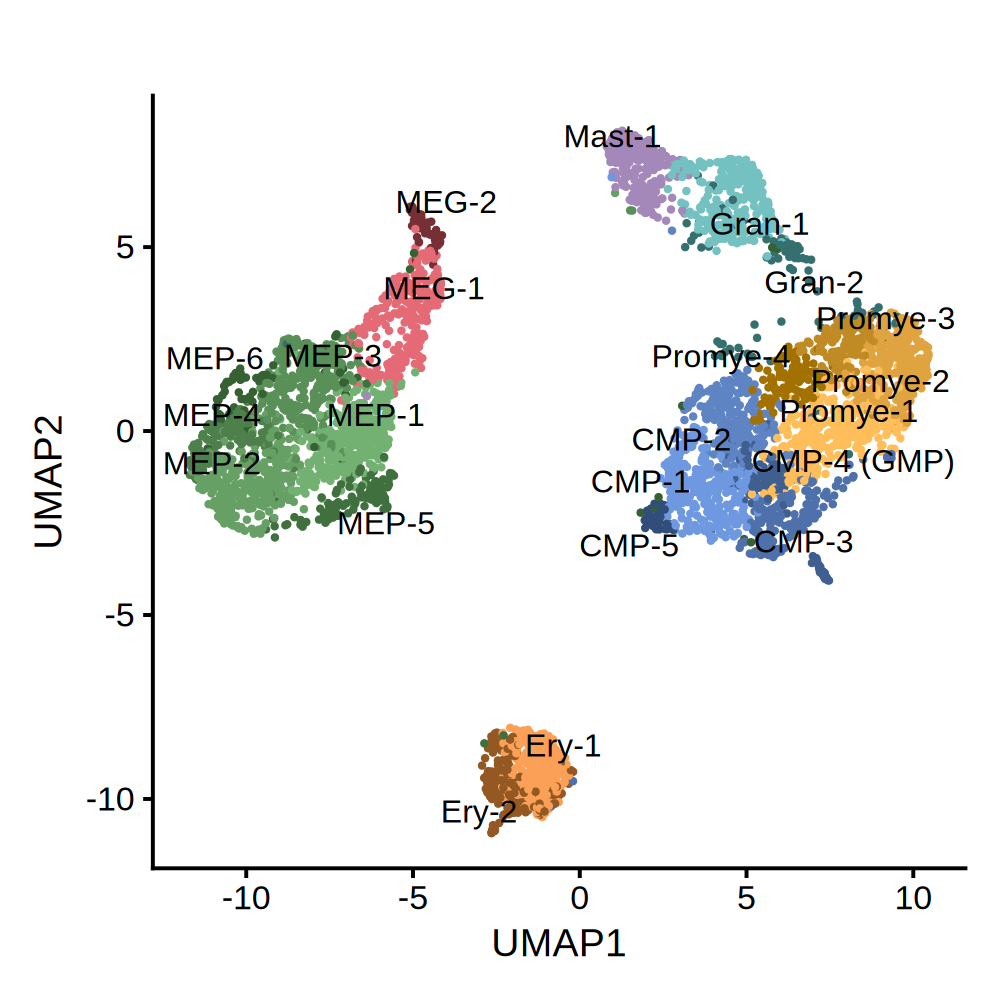

In [9]:
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 200)

p_clust = DimPlot(seu, label = TRUE, group.by = 'manual_label_subclust', repel = TRUE,
                  cols = subclust_colors) +
    theme(legend.position = 'none') +
    ggtitle('') +
    xlab('UMAP1') +
    ylab('UMAP2')

p_clust

ggsave('outputs/substate_umap.pdf', p_clust, w = 5, h = 5)

In [7]:
phy_annot = read.tree('../../../plarry/results/final/pL1000_full/tree_annotated.newick')
mut_dat = fread(glue('../../../plarry/mut_dat/final/pL1000_full_mut_dat.csv'))

Registered S3 method overwritten by 'TreeTools':
  method   from    
  [.phyDat phangorn

Found more than one class "phylo" in cache; using the first, from namespace 'tidytree'

Also defined by ‘TreeTools’

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


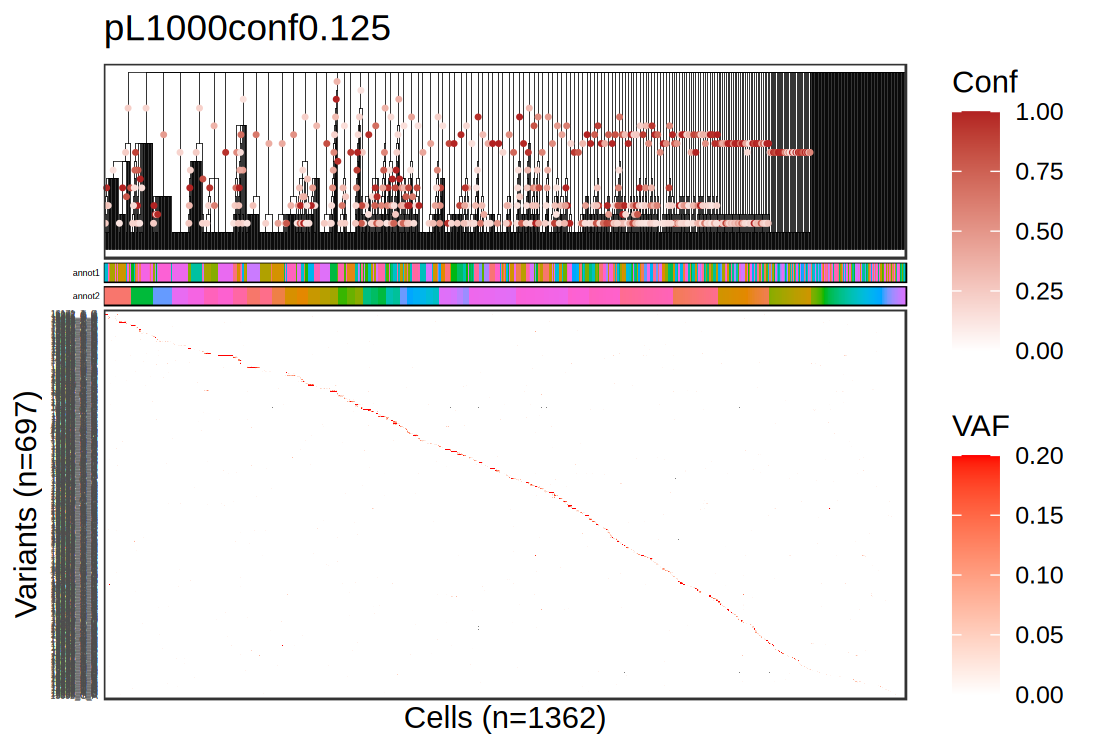

In [8]:
options(repr.plot.width = 5.5, repr.plot.height = 3.75, repr.plot.res = 200)

p_conf = 0.125
phy_trim = phy_annot %>% trim_tree(conf = p_conf)
clade_annot = assign_clones_polytomy(phy_trim)

plot_phylo_heatmap2(
    phy_trim,
    mut_dat,
    branch_length = F,
    branch_width = 0.1,
    het_max = 0.2,
    annot_legend = F,
    node_conf = T,
    conf_max = 1,
    conf_min = 0,
    cell_annot = list(barcode_annot, clade_annot),
    # annot_pal = list(barcode_pal, clade_pal),
    # cell_annot = barcode_annot,
    # annot_pal = barcode_pal,
    # cell_annot = data.frame(cell = doublets) %>% mutate(annot = 'doublet'),
    title = paste0(donor, 'conf', p_conf)
) %>% suppressWarnings()

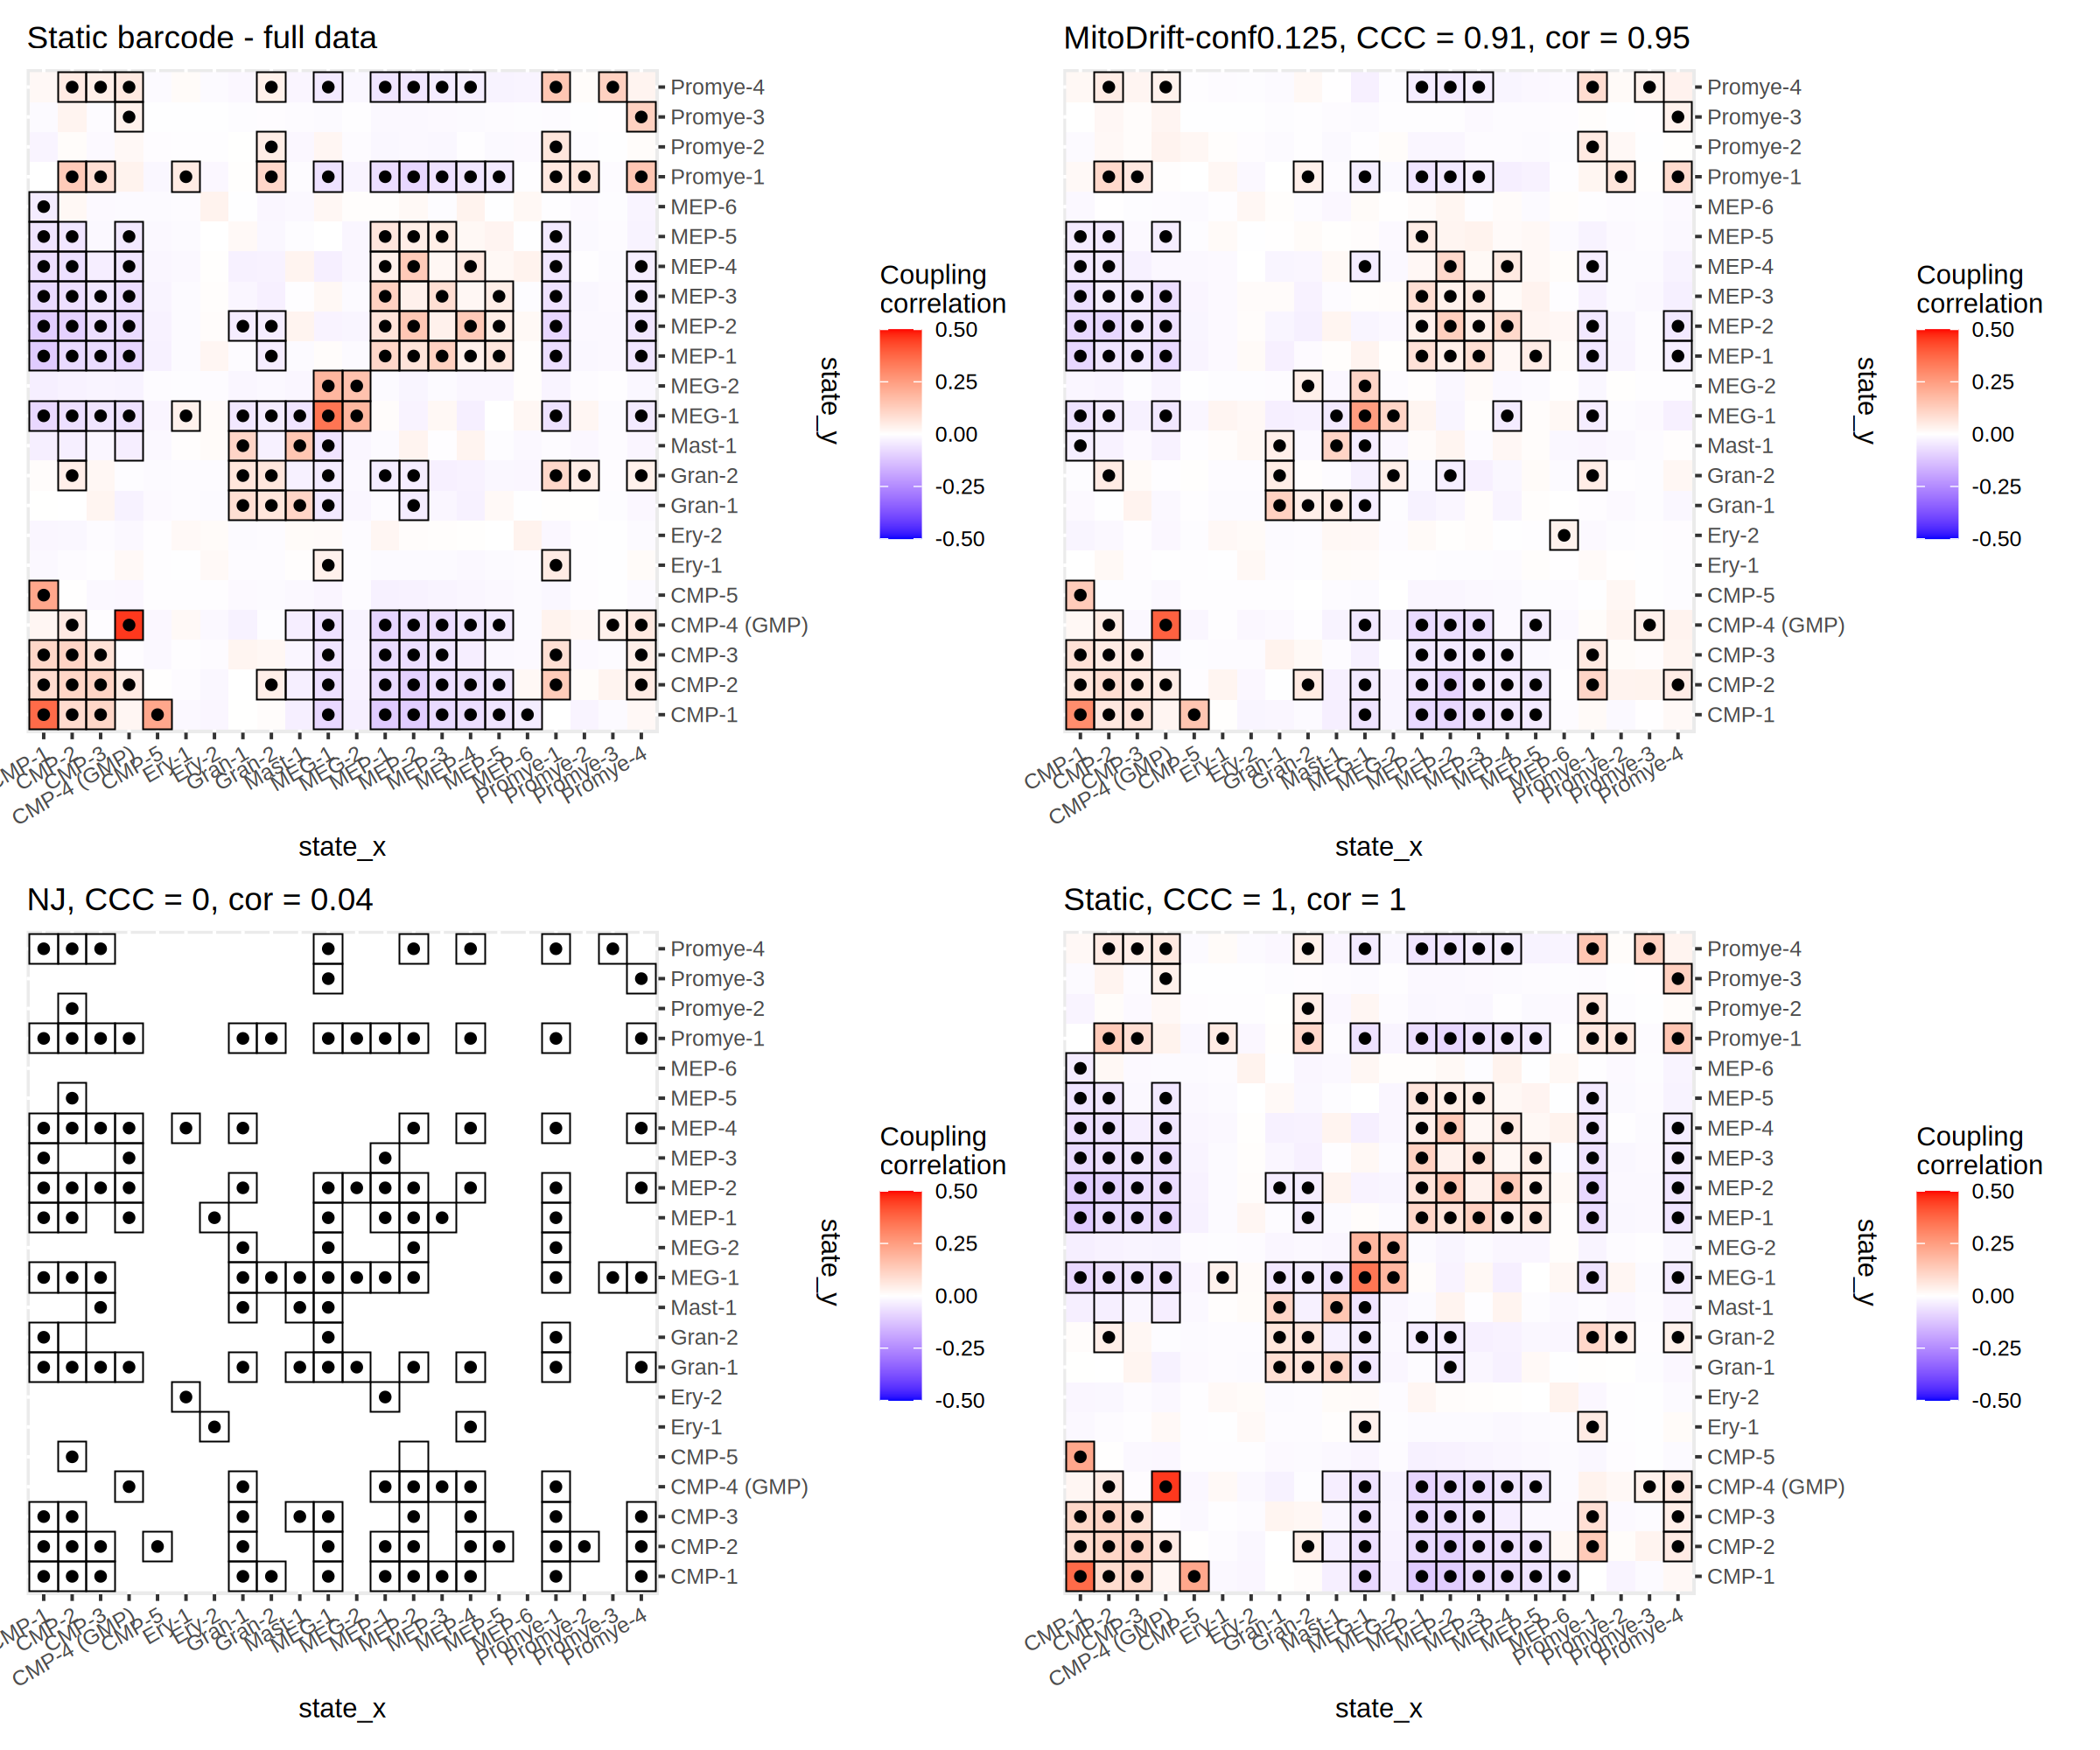

In [16]:
options(repr.plot.width = 12, repr.plot.height = 10, repr.plot.res = 200)
# source('../../../scripts/utils.R')

conf = 0.125
model = 'bm'
rescale = F
limits = c(-0.5,0.5)

res_path_tru = run_path(phy_tru, ct_dict, model = model)

cor_mat_tru = res_path_tru %>% 
    reshape2::dcast(state_x ~ state_y, value.var = 'cor') %>% 
    tibble::column_to_rownames('state_x') %>% as.matrix

phy_trim = phy_annot %>% trim_tree(conf = conf)
res_trim = run_path(phy_trim, ct_dict, model = model)
res_nj = run_path(phy_annot, ct_dict, model = model)
res_path_static = run_path(phy_tru, ct_dict, model = model)

cor_mat_static = res_path_static %>% 
    reshape2::dcast(state_x ~ state_y, value.var = 'cor') %>%
    tibble::column_to_rownames('state_x') %>% as.matrix

cor_mat_nj = res_nj %>% 
    reshape2::dcast(state_x ~ state_y, value.var = 'cor') %>% 
    tibble::column_to_rownames('state_x') %>% as.matrix

cor_mat_trim = res_trim %>% 
    reshape2::dcast(state_x ~ state_y, value.var = 'cor') %>% 
    tibble::column_to_rownames('state_x') %>% as.matrix

cor_static = matrix_cor_test(cor_mat_tru, cor_mat_static)$estimate %>% round(2)
cor_trim = matrix_cor_test(cor_mat_tru, cor_mat_trim)$estimate %>% round(2)
cor_nj = matrix_cor_test(cor_mat_tru, cor_mat_nj)$estimate %>% round(2)

score_static = matrix_ccc(cor_mat_tru, cor_mat_static) %>% round(2)
score_trim = matrix_ccc(cor_mat_tru, cor_mat_trim) %>% round(2)
score_nj = matrix_ccc(cor_mat_tru, cor_mat_nj) %>% round(2)


state_order = sort(unique(ct_dict))
state_order = state_order[state_order %in% res_trim$state_x]

p1 = plot_res_path(res_path_tru, state_order, limits = limits) + 
    ggtitle('Static barcode - full data')
p2 = plot_res_path(res_trim, state_order, limits = limits) + 
    ggtitle(glue('MitoDrift-conf{conf}, CCC = {score_trim}, cor = {cor_trim}'))
p3 = plot_res_path(res_nj, state_order, limits = limits) + 
    ggtitle(glue('NJ, CCC = {score_nj}, cor = {cor_nj}'))
p4 = plot_res_path(res_path_static, state_order, limits = limits) + 
    ggtitle(glue('Static, CCC = {score_static}, cor = {cor_static}'))

wrap_plots(p1, p2, p3, p4)

In [14]:
R.utils::sourceDirectory('../../R')
model = 'bm'
p_conf = 0.125

res_path = list()

phy_list = list(
    'Static' = phy_tru,
    'NJ' = phy_annot,
    'MitoDrift' = trim_tree(phy_annot, conf = p_conf)
)

res_path_all = lapply(
    phy_list,
    function(phy) {
        run_path(phy, ct_dict, model = model)
    }
)

cor_mat_all = lapply(
    res_path_all,
    function(res) {
        cor_mat = res %>% 
            reshape2::dcast(state_x ~ state_y, value.var = 'cor') %>% 
            tibble::column_to_rownames('state_x') %>% as.matrix        
    }
)

scores_all = lapply(
    cor_mat_all,
    function(cor_mat) {
        ccc = matrix_ccc(cor_mat_all[['Static']], cor_mat, diag = T) %>% round(2)
        cor = matrix_cor_test(cor_mat_all[['Static']], cor_mat, diag = T)$estimate %>% round(2)
        list(cor = cor, ccc = ccc)
    }
)

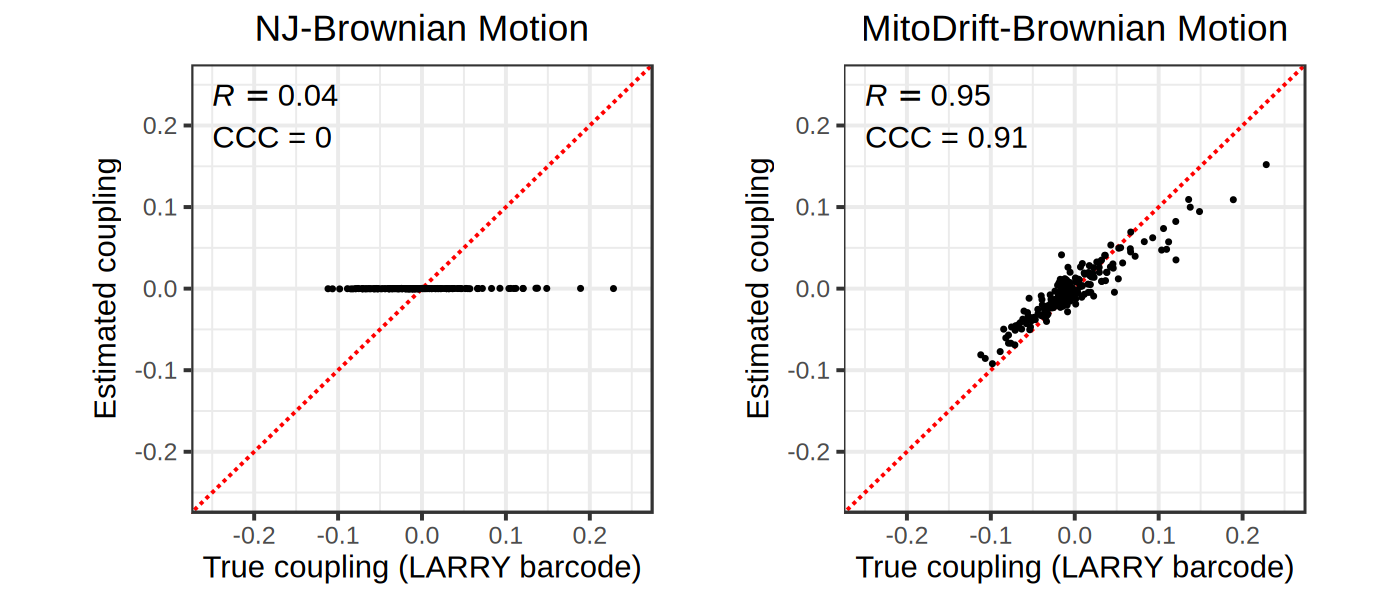

In [15]:
options(repr.plot.width = 7, repr.plot.height = 3, repr.plot.res = 200)

limits = c(-0.25,0.25)

model_labels = c('bm' = 'Brownian Motion', 'sibling' = 'Sibling')

p = lapply(
    names(phy_list[-1]),
    function(method) {
        ccc = scores_all[[method]]$ccc
        cor = scores_all[[method]]$cor
        inner_join(
            res_path_all[[method]] %>% 
                select(state_x, state_y, cor_est = cor) %>%
                filter(as.integer(state_x) > as.integer(state_y)),
            res_path_all[['Static']] %>% 
                select(state_x, state_y, cor_tru = cor) %>%
                filter(as.integer(state_x) > as.integer(state_y)),
            by = join_by(state_x, state_y)
        ) %>%
        ggplot(
            aes(x = cor_tru, y = cor_est)
        ) +
        geom_abline(linetype = 'dashed', color = 'red') +
        geom_point(size = 0.25) +
        scale_x_continuous(limits = limits) +
        scale_y_continuous(limits = limits) +
        annotate(
            'text',
            x = limits[1],
            y = limits[2],
            hjust = 0,
            vjust = 1,
            label = glue::glue("italic(R) == {round(cor, 3)}"),
            parse = T
        ) +
        annotate(
            'text',
            x = limits[1],
            y = limits[2],
            hjust = 0,
            vjust = 3,
            label = glue::glue('CCC = {round(ccc, 3)}')
        ) +
        ggtitle(paste0(method, '-', model_labels[model])) +
        theme_bw() +
        theme(plot.title = element_text(hjust = 0.5)) +
        xlab('True coupling (LARRY barcode)') +
        ylab('Estimated coupling')
    }
) %>% wrap_plots(nrow = 1) & 
theme(plot.margin = margin(t = 1, r = 6, b = 1, l = 6, unit = "mm")) &
theme_transparent

p

ggsave(glue('outputs/coupling_scatter_{model}.pdf'), p, w = 7, h = 3)

In [24]:
cor_mat_tru = res_path_all[['Static']] %>% 
    reshape2::dcast(state_x ~ state_y, value.var = 'cor') %>% 
    tibble::column_to_rownames('state_x') %>% as.matrix

df_cts = seu@meta.data %>%
    mutate(manual_label = str_split(manual_label_subclust, '-') %>% purrr::map(1)) %>%
    distinct(manual_label, manual_label_subclust) %>% 
    arrange(manual_label) %>%
    mutate(manual_label = as.character(manual_label), manual_label_subclust = as.character(manual_label_subclust))

cts = unique(df_cts$manual_label)

order_dict = lapply(
    cts,
    function(ct) {
        states = df_cts %>% filter(manual_label == ct) %>% pull(manual_label_subclust)
        if (length(states) > 2) {
            hc = hclust(as.dist(1-cor_mat_tru[states,states]))
            hc$labels[hc$order]
        } else {
            sort(states)
        }
}) %>% setNames(cts)

ct_order = c('CMP', 'Promye', 'Gran', 'Mast', 'Ery', 'MEG', 'MEP')
state_order = unlist(order_dict[ct_order])

In [25]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 200)

rescale = T
limits = c(-0.25,0.25)

lapply(
    names(res_path_all),
    function(method) {
        p = plot_coupling_triangle(res_path_all[[method]], state_order, limits = limits, mark_signif = F) +
            theme(axis.text.x = element_text(angle = 90, hjust = 1))

        if (method == names(res_path_all)[1]) {
            leg = ggpubr::get_legend(p)
            ggsave('outputs/coupling_heatmap_legend.pdf', leg, w = 1.5, h = 2)
        }
        
        ggsave(
            glue('outputs/{method}_coupling_heatmap.pdf'),
            p + theme(legend.position = 'none'),
            w = 5, h = 4
        )
    }
)

[[1]]
outputs/Static_coupling_heatmap.pdf

[[2]]
outputs/NJ_coupling_heatmap.pdf

[[3]]
outputs/MitoDrift_coupling_heatmap.pdf

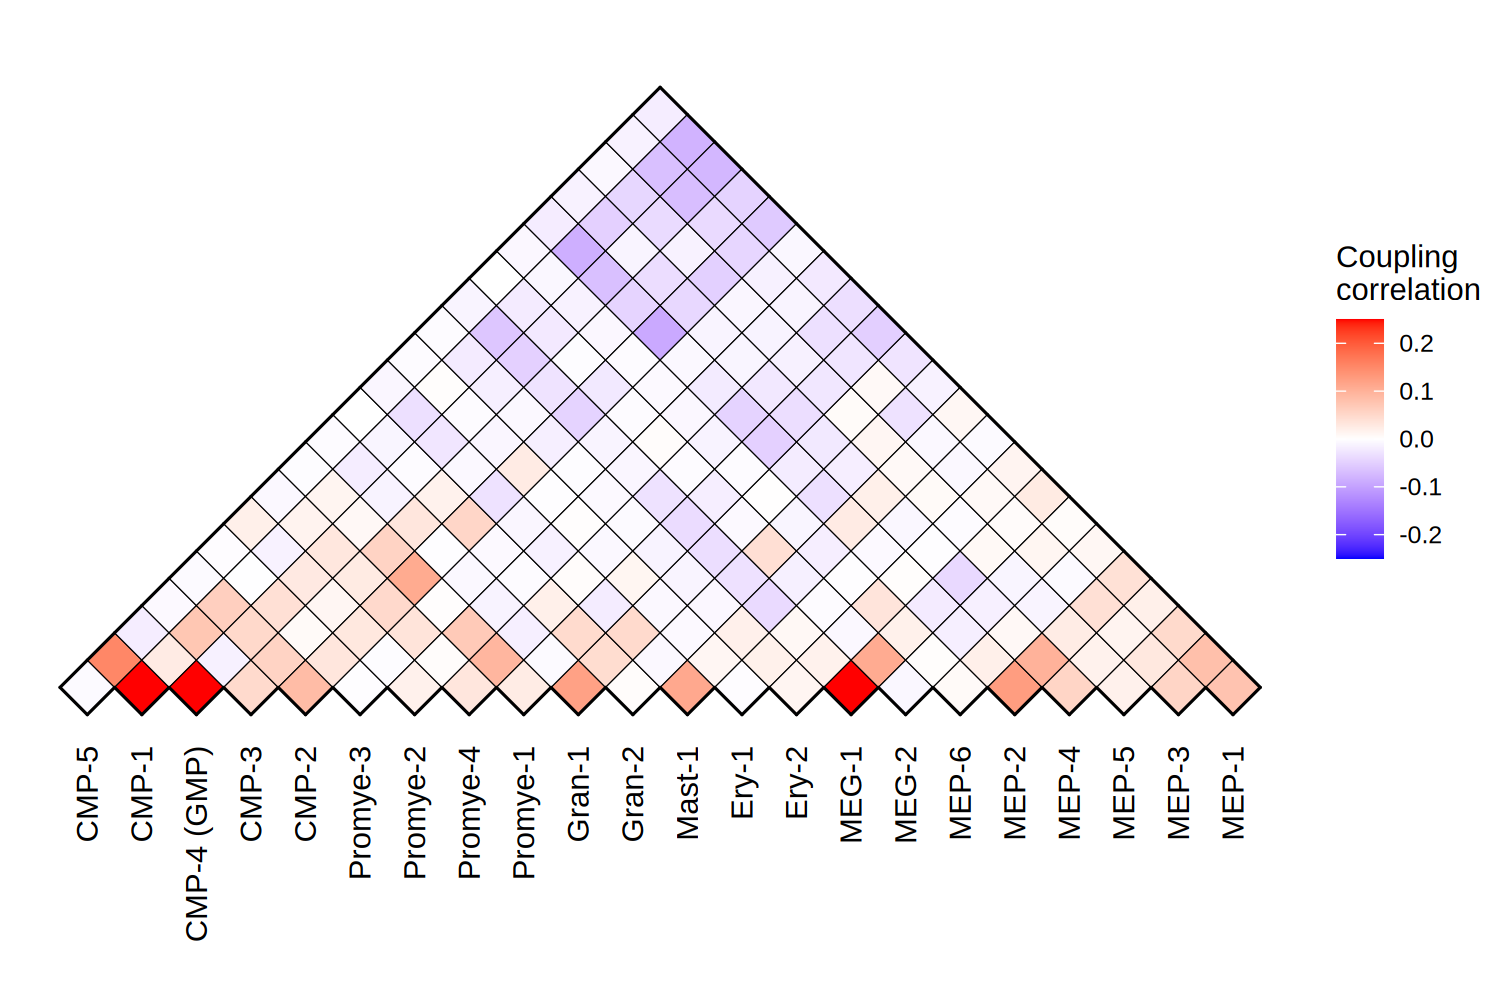

In [26]:
options(repr.plot.width = 7.5, repr.plot.height = 5, repr.plot.res = 200)

method = 'MitoDrift'

plot_coupling_triangle(res_path_all[[method]], state_order, limits = limits, mark_signif = F) +
theme(axis.text.x = element_text(angle = 90, hjust = 1))